In [1]:
print("Hello World")

Hello World


## Flow diagram

![Sentiment routing flowchart](images/tweet_sentiment.png)


In [25]:
MODEL = "gemma3:4b"
OLLAMA_BASE_URL = "http://localhost:11434/"

OLLAMA_API_KEY="f198123e57584fcc9ae238c4bf6ed9a0.7vtr5Vz7-5_qXO1v_w_P0_6I"

In [33]:
from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END

In [21]:
llm = ChatOllama(
  model=MODEL,
  base_url=OLLAMA_BASE_URL,
  validate_model_on_init=True,
)
llm

ChatOllama(model='gemma3:4b', validate_model_on_init=True, base_url='http://localhost:11434/')

In [5]:
class SentimentAnalysis(BaseModel):
  sentiment: Literal["positive", "negative"] = Field(description="The sentiment classification either positive or negative")
  confidence: float = Field(ge=0, le=1.0, description="Confidence score from 0.0 to 1.0")
  reason: str = Field(description="Brief Explaination")

# State
class SentimentState(TypedDict):
  original_tweet: str
  sentiment: str
  confidence: float

  response_tweet: str

In [ ]:
## NODES

def analyze_sentiment(state: SentimentState) -> SentimentState:
  print("NODE [analyze_sentiment]")
  tweet = state['original_tweet']

  structured_llm = llm.with_structured_output(SentimentAnalysis)
  messages = [
    SystemMessage("Analyze sentiment and provide the structured output. Use 0 to 1.0 scale for condifence. Lower is negative and Higher is positive."),
    HumanMessage(tweet)
  ]

  analysis = structured_llm.invoke(messages)

  # return {
  #   "sentiment": analysis.sentiment,
  #   'confidence': analysis.confidence
  # }
  return SentimentState(analysis)

def generate_positive_response(state:SentimentState) -> SentimentState:
  print("NODE [generate_positive_response]")
  messages = [
        SystemMessage(f"""Generate a warm response to this positive tweet under 280 chars.
                      Confidence: {state['confidence']}. High confidence means be enthusiastic otherwise be friendly."""),
        HumanMessage(state['original_tweet'])
    ]


  response = llm.invoke(messages)
  print("P RESPONSE: ", response)
  return {'response_tweet': response.content.strip()}


def generate_negative_response(state: SentimentState):
  print("NODE [generate_negative_response]")

  messages = [
        SystemMessage(f"""Generate and empathetic response to this negative tweet under 280 chars.
                      If Confidence {state['confidence']} is very low then be empathetic otherwise 
                      be understanding."""),
        HumanMessage(state['original_tweet'])
    ]

  response = llm.invoke(messages)
  print('N RESPONSE: ', response)
  return {'response_tweet': response.content.strip()}

def route_by_sentiment(state: SentimentState):
  if state['sentiment'] == "positive": 
    return 'positive_response'
  return "negative_response"

In [18]:
state = {"original_tweet": "Just launched my product"}
resp = analyze_sentiment(state)


Analyzing customer tweet: Just launched my product
Sentiment Analysis is done: 
 sentiment='positive' confidence=0.85 reason="The phrase 'Just launched' indicates a successful and exciting event, strongly suggesting enthusiasm and optimism about the new product."


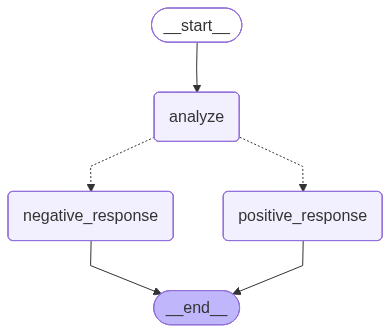

In [34]:
def create_router_graph():
  builder = StateGraph(SentimentState)

  builder.add_node("analyze", analyze_sentiment)
  builder.add_node("positive_response", generate_positive_response)
  builder.add_node("negative_response", generate_negative_response)

  builder.add_edge(START, "analyze")

  builder.add_conditional_edges("analyze", route_by_sentiment, ["positive_response", "negative_response"])

  builder.add_edge("positive_response", END)
  builder.add_edge("negative_response", END)

  graph = builder.compile()
  return graph

create_router_graph()

In [35]:
state = {
  "original_tweet": "Loved this Product. I will use this regularly for sure!"
}

In [36]:
create_router_graph().invoke(state)

NODE [analyze_sentiment]
NODE [generate_positive_response]
P RESPONSE:  content="That’s fantastic to hear! 🎉 We're so thrilled you're loving it and will be using it regularly. 😊 Thanks for the awesome feedback! ✨ \n" additional_kwargs={} response_metadata={'model': 'gemma3:4b', 'created_at': '2026-04-12T11:53:43.058350213Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6886714723, 'load_duration': 317880399, 'prompt_eval_count': 60, 'prompt_eval_duration': 3106821483, 'eval_count': 36, 'eval_duration': 3421400041, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'} id='lc_run--019d818a-46aa-7561-aac9-22e20c3d576e-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 60, 'output_tokens': 36, 'total_tokens': 96}


{'original_tweet': 'Loved this Product. I will use this regularly for sure!',
 'sentiment': 'positive',
 'confidence': 0.95,
 'response_tweet': "That’s fantastic to hear! 🎉 We're so thrilled you're loving it and will be using it regularly. 😊 Thanks for the awesome feedback! ✨"}

In [ ]:
state = {
  "original_tweet": "Useless Product. I will never use this!"
}

In [39]:
create_router_graph().invoke(state)

NODE [analyze_sentiment]
NODE [generate_negative_response]
N RESPONSE:  content="Okay, I'm so sorry to hear you had such a frustrating experience! It's completely valid to feel disappointed when something doesn't meet your expectations.  I genuinely appreciate you sharing your feedback – it helps others. ❤️" additional_kwargs={} response_metadata={'model': 'gemma3:4b', 'created_at': '2026-04-12T12:15:06.017019313Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8210870301, 'load_duration': 371185108, 'prompt_eval_count': 62, 'prompt_eval_duration': 2948876538, 'eval_count': 48, 'eval_duration': 4838639469, 'logprobs': None, 'model_name': 'gemma3:4b', 'model_provider': 'ollama'} id='lc_run--019d819d-d50c-7032-ac7f-5c562382f215-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 62, 'output_tokens': 48, 'total_tokens': 110}


{'original_tweet': 'Useless Product. I will never use this!',
 'sentiment': 'negative',
 'confidence': 0.95,
 'response_tweet': "Okay, I'm so sorry to hear you had such a frustrating experience! It's completely valid to feel disappointed when something doesn't meet your expectations.  I genuinely appreciate you sharing your feedback – it helps others. ❤️"}